In [11]:
import pandas as pd
import copy
import spacy

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
nlp = spacy.load('de_core_news_lg')

all_party_textes_df = pd.read_parquet("all_parties_text_combined_prep.parquet")
labled_theses_df = pd.read_csv('wahlomaten_thesen_positionen.csv')

In [16]:
all_party_textes_df.columns

Index(['Party', 'Chapter', 'These', 'Text', 'Text_no_stopwords',
       'These_no_stopwords', 'Text_lemmatized', 'These_lemmatized',
       'These_unique_words'],
      dtype='object')

In [3]:
lable_mapping_dict = {
    "stimme nicht zu": 1/6, # 0,00 - 0,33 
    "neutral": 3/6,         # 0,33 - 0,66 
    "stimme zu": 5/6        # 0,66 - 1,00
}

label_these_num_df = labled_theses_df.copy()
for col in labled_theses_df.columns[1:]:
    label_these_num_df[col] = labled_theses_df[col].map(lable_mapping_dict)

del lable_mapping_dict

label_these_num_df.head()

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.166667,0.166667,0.166667,0.166667,0.833333,0.166667
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.166667,0.833333,0.833333,0.166667,0.833333,0.166667
2,An Bahnhöfen soll die Bundespolizei Software z...,0.833333,0.166667,0.166667,0.833333,0.166667,0.166667
3,Asylsuchende sollen in Deutschland sofort nach...,0.166667,0.833333,0.833333,0.166667,0.833333,0.500000
4,"Asylsuchende, die über einen anderen EU-Staat ...",0.833333,0.166667,0.166667,0.833333,0.166667,0.833333


In [4]:
lable_colums_list = labled_theses_df.columns[1:].tolist()

replace_dict = {
    'spd'   :   'SPD', 
    'cdu'   :   'CDU / CSU', 
    'gruene':   'GRÜNE', 
    'afd'   :   'AfD',
    'fdp'   :   'FDP', 
    'linke' :   'Die Linke'
}

all_party_textes_df['Party'] = all_party_textes_df['Party'].replace(replace_dict)
del replace_dict
parties_list = all_party_textes_df['Party'].unique().tolist()

In [ ]:
def spacy_similarity_score_func(all_party_textes_df:pd.DataFrame, labled_theses_df:pd.DataFrame, content:str = 'These', plot:bool = False)->pd.DataFrame:    
    parties_list = all_party_textes_df['Party'].unique().tolist()
    Labled_theses_list = labled_theses_df['These'].tolist()
    predicted_theses_df = copy.deepcopy(labled_theses_df)

    all_party_textes_df['Chapter'] = all_party_textes_df['Chapter'].fillna('-')


    for party_str in parties_list:
        party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]
        party_df = party_df.dropna()
        party_these_list = party_df[content].to_list()

        similarity_df = pd.DataFrame(columns=['party_these']+Labled_theses_list)

        for party_these in party_these_list:
            party_these_doc = nlp(party_these)
            row = [party_these]
            for label_these in Labled_theses_list:
                label_these_doc = nlp(label_these)
                similarity_score = party_these_doc.similarity(label_these_doc)
                row = row + [similarity_score]
            similarity_df.loc[len(similarity_df)] = row

        if plot:
            plt.figure(figsize=(18,18))
            sns.heatmap(similarity_df[Labled_theses_list], 
                        cmap='RdYlGn', 
                        annot= False,
                        vmax= 1,
                        vmin= 0,
                        yticklabels=party_df["These"])
            plt.xticks(rotation=45, ha="right")
            plt.title(f"Thesen-Heatmap: {party_str}")
            plt.show()

        predicted_theses_df[party_str] = similarity_df[Labled_theses_list].max().tolist()
    
    return predicted_theses_df


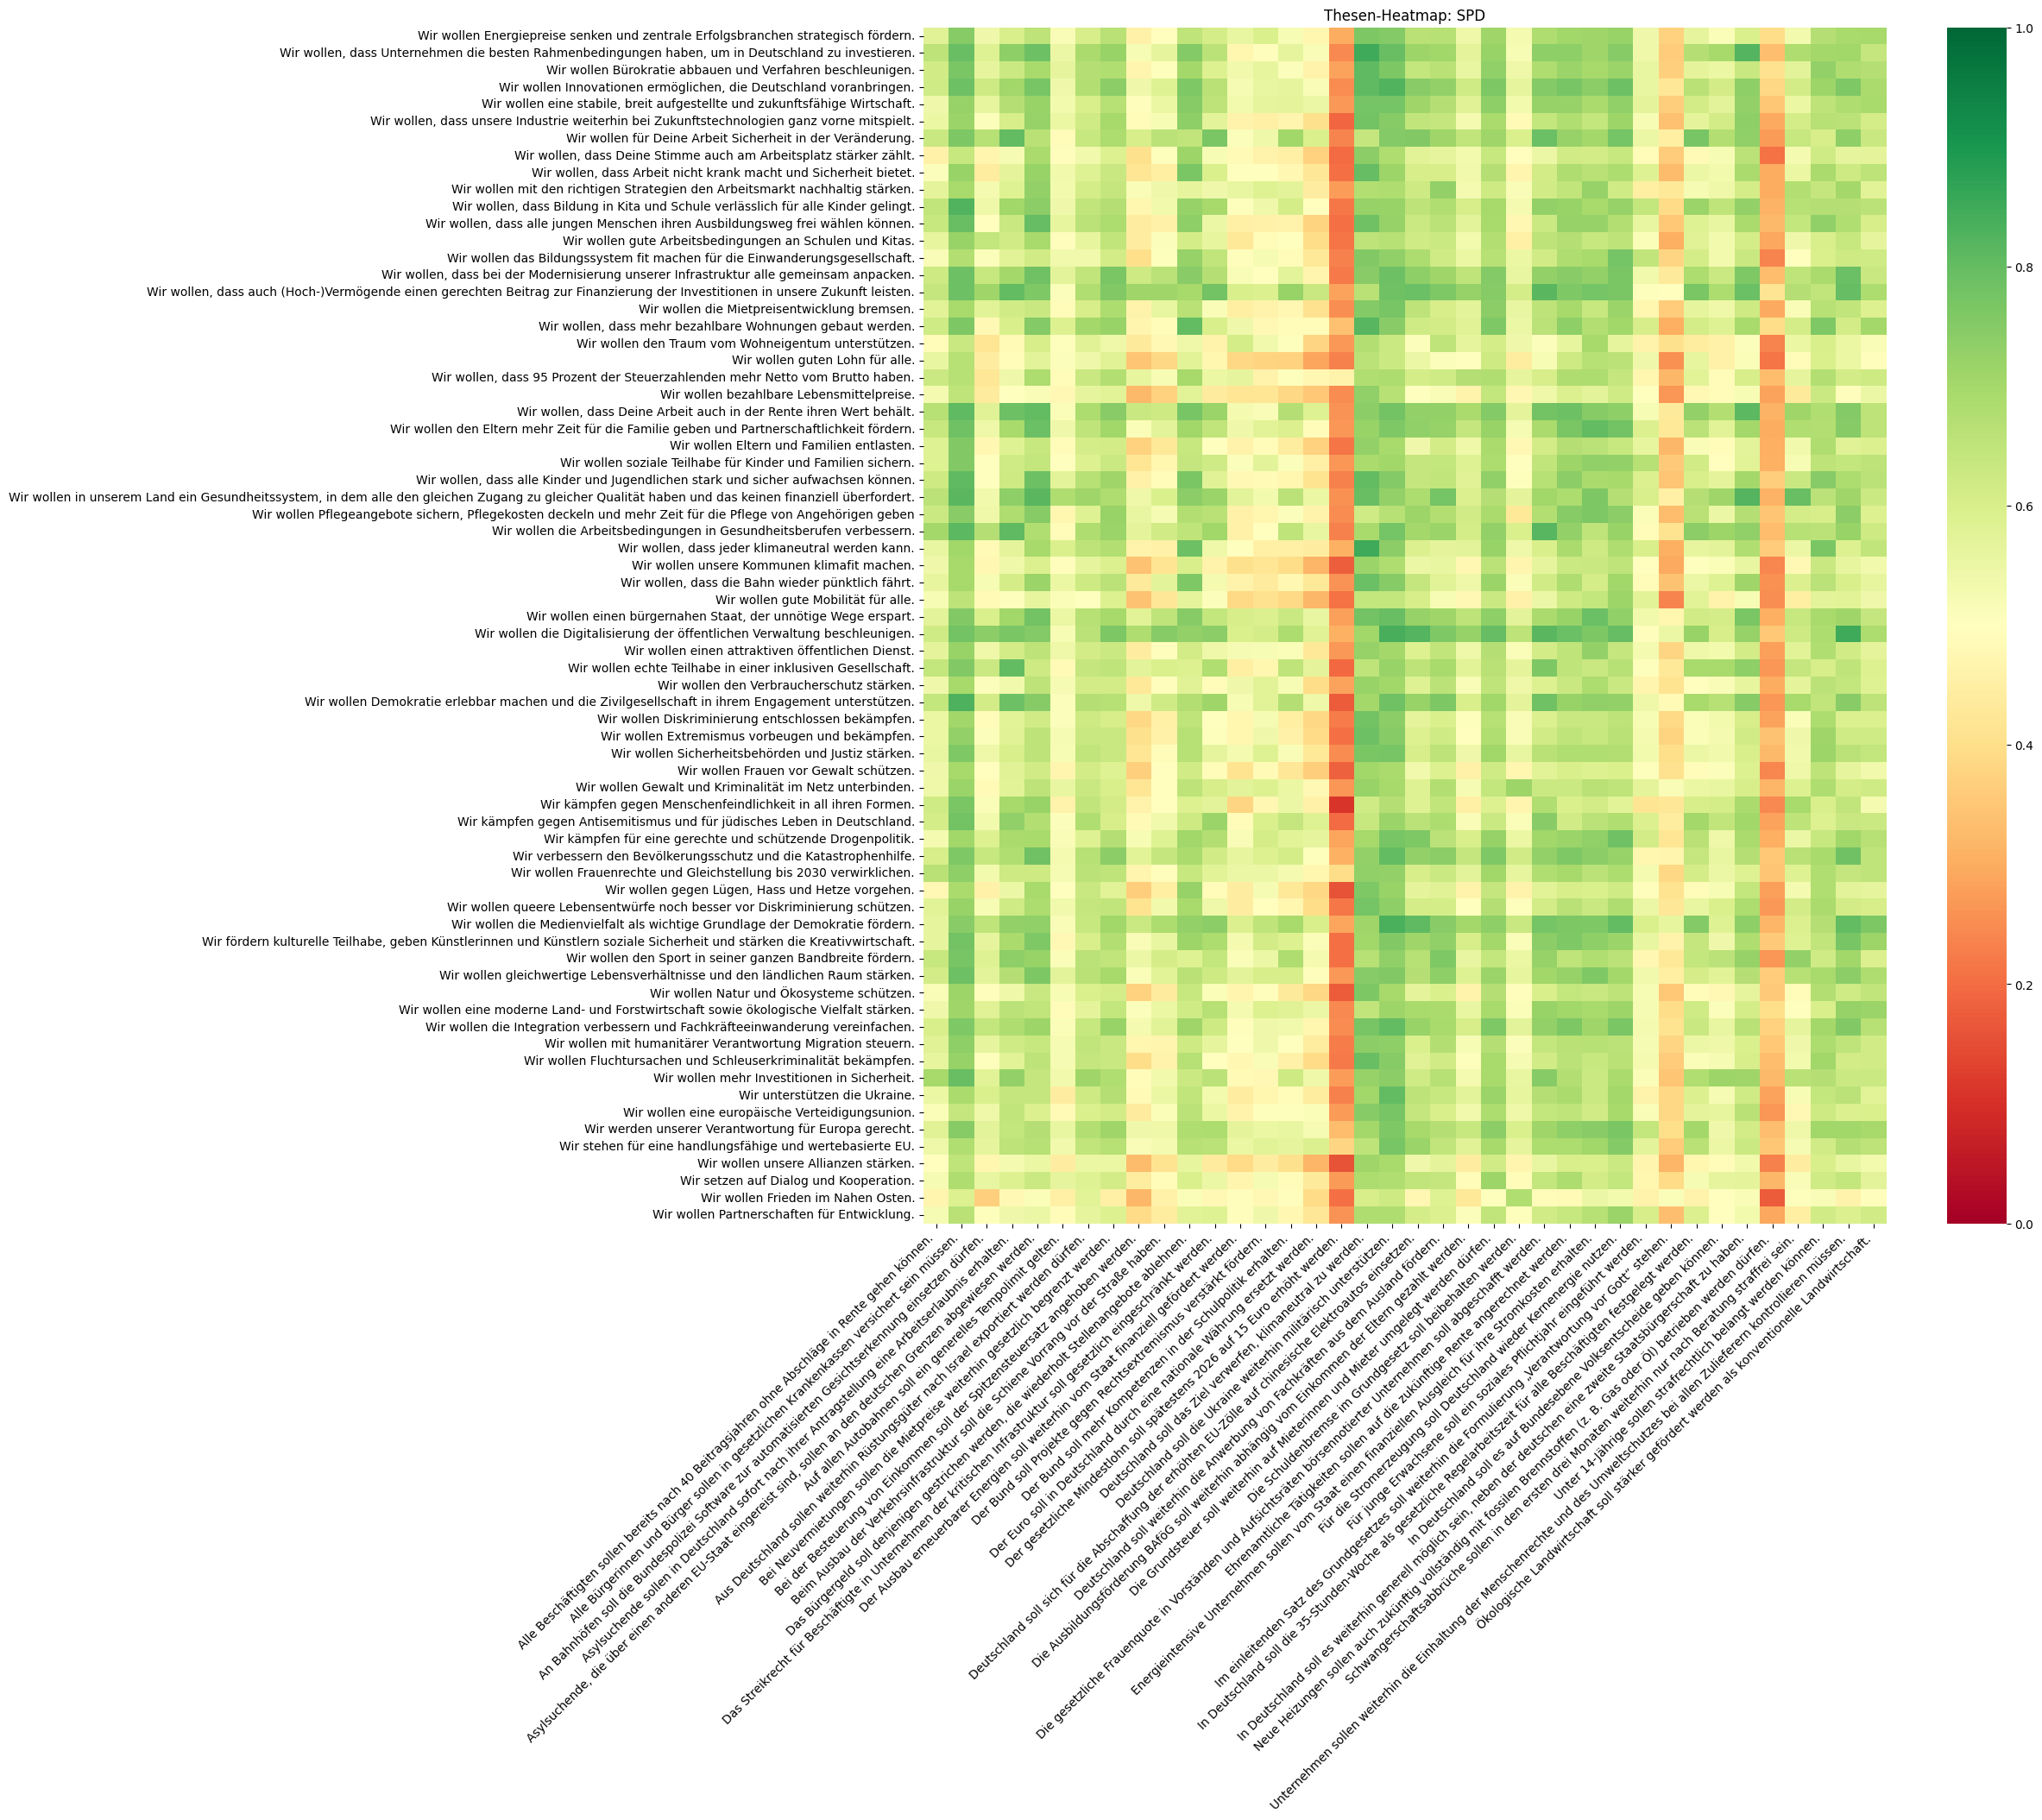

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2568\3420323385.py:21: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)


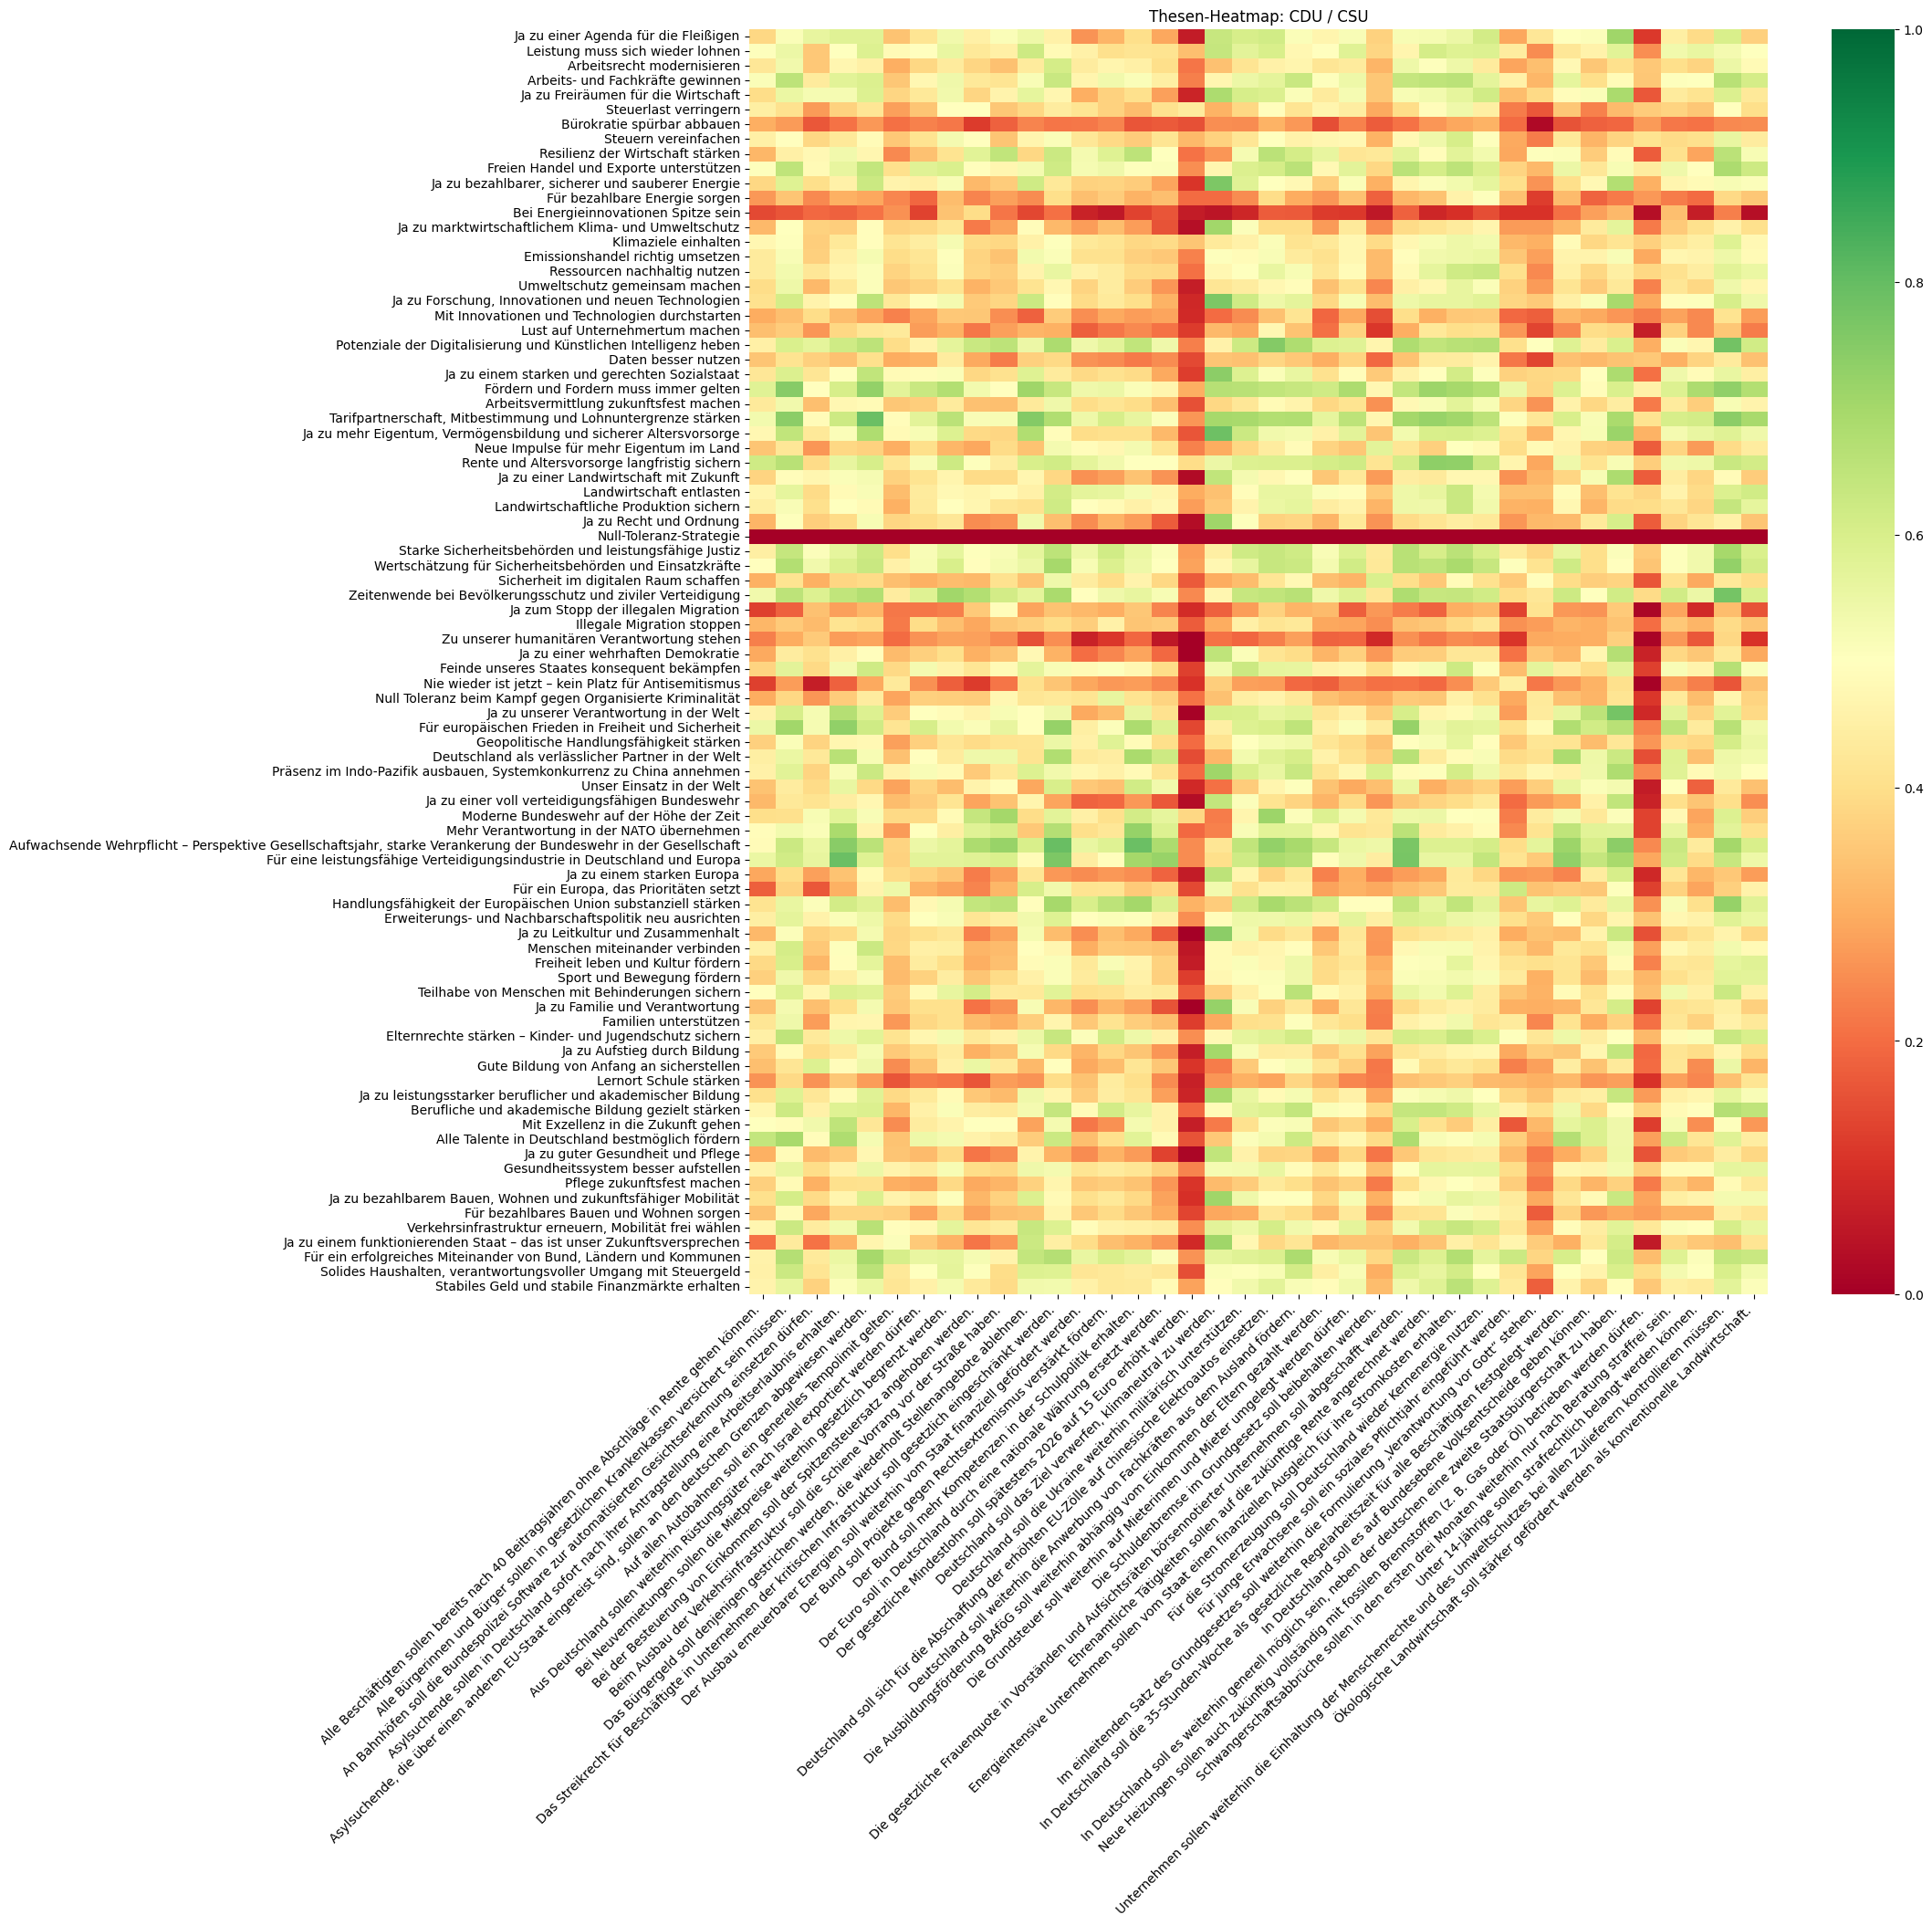

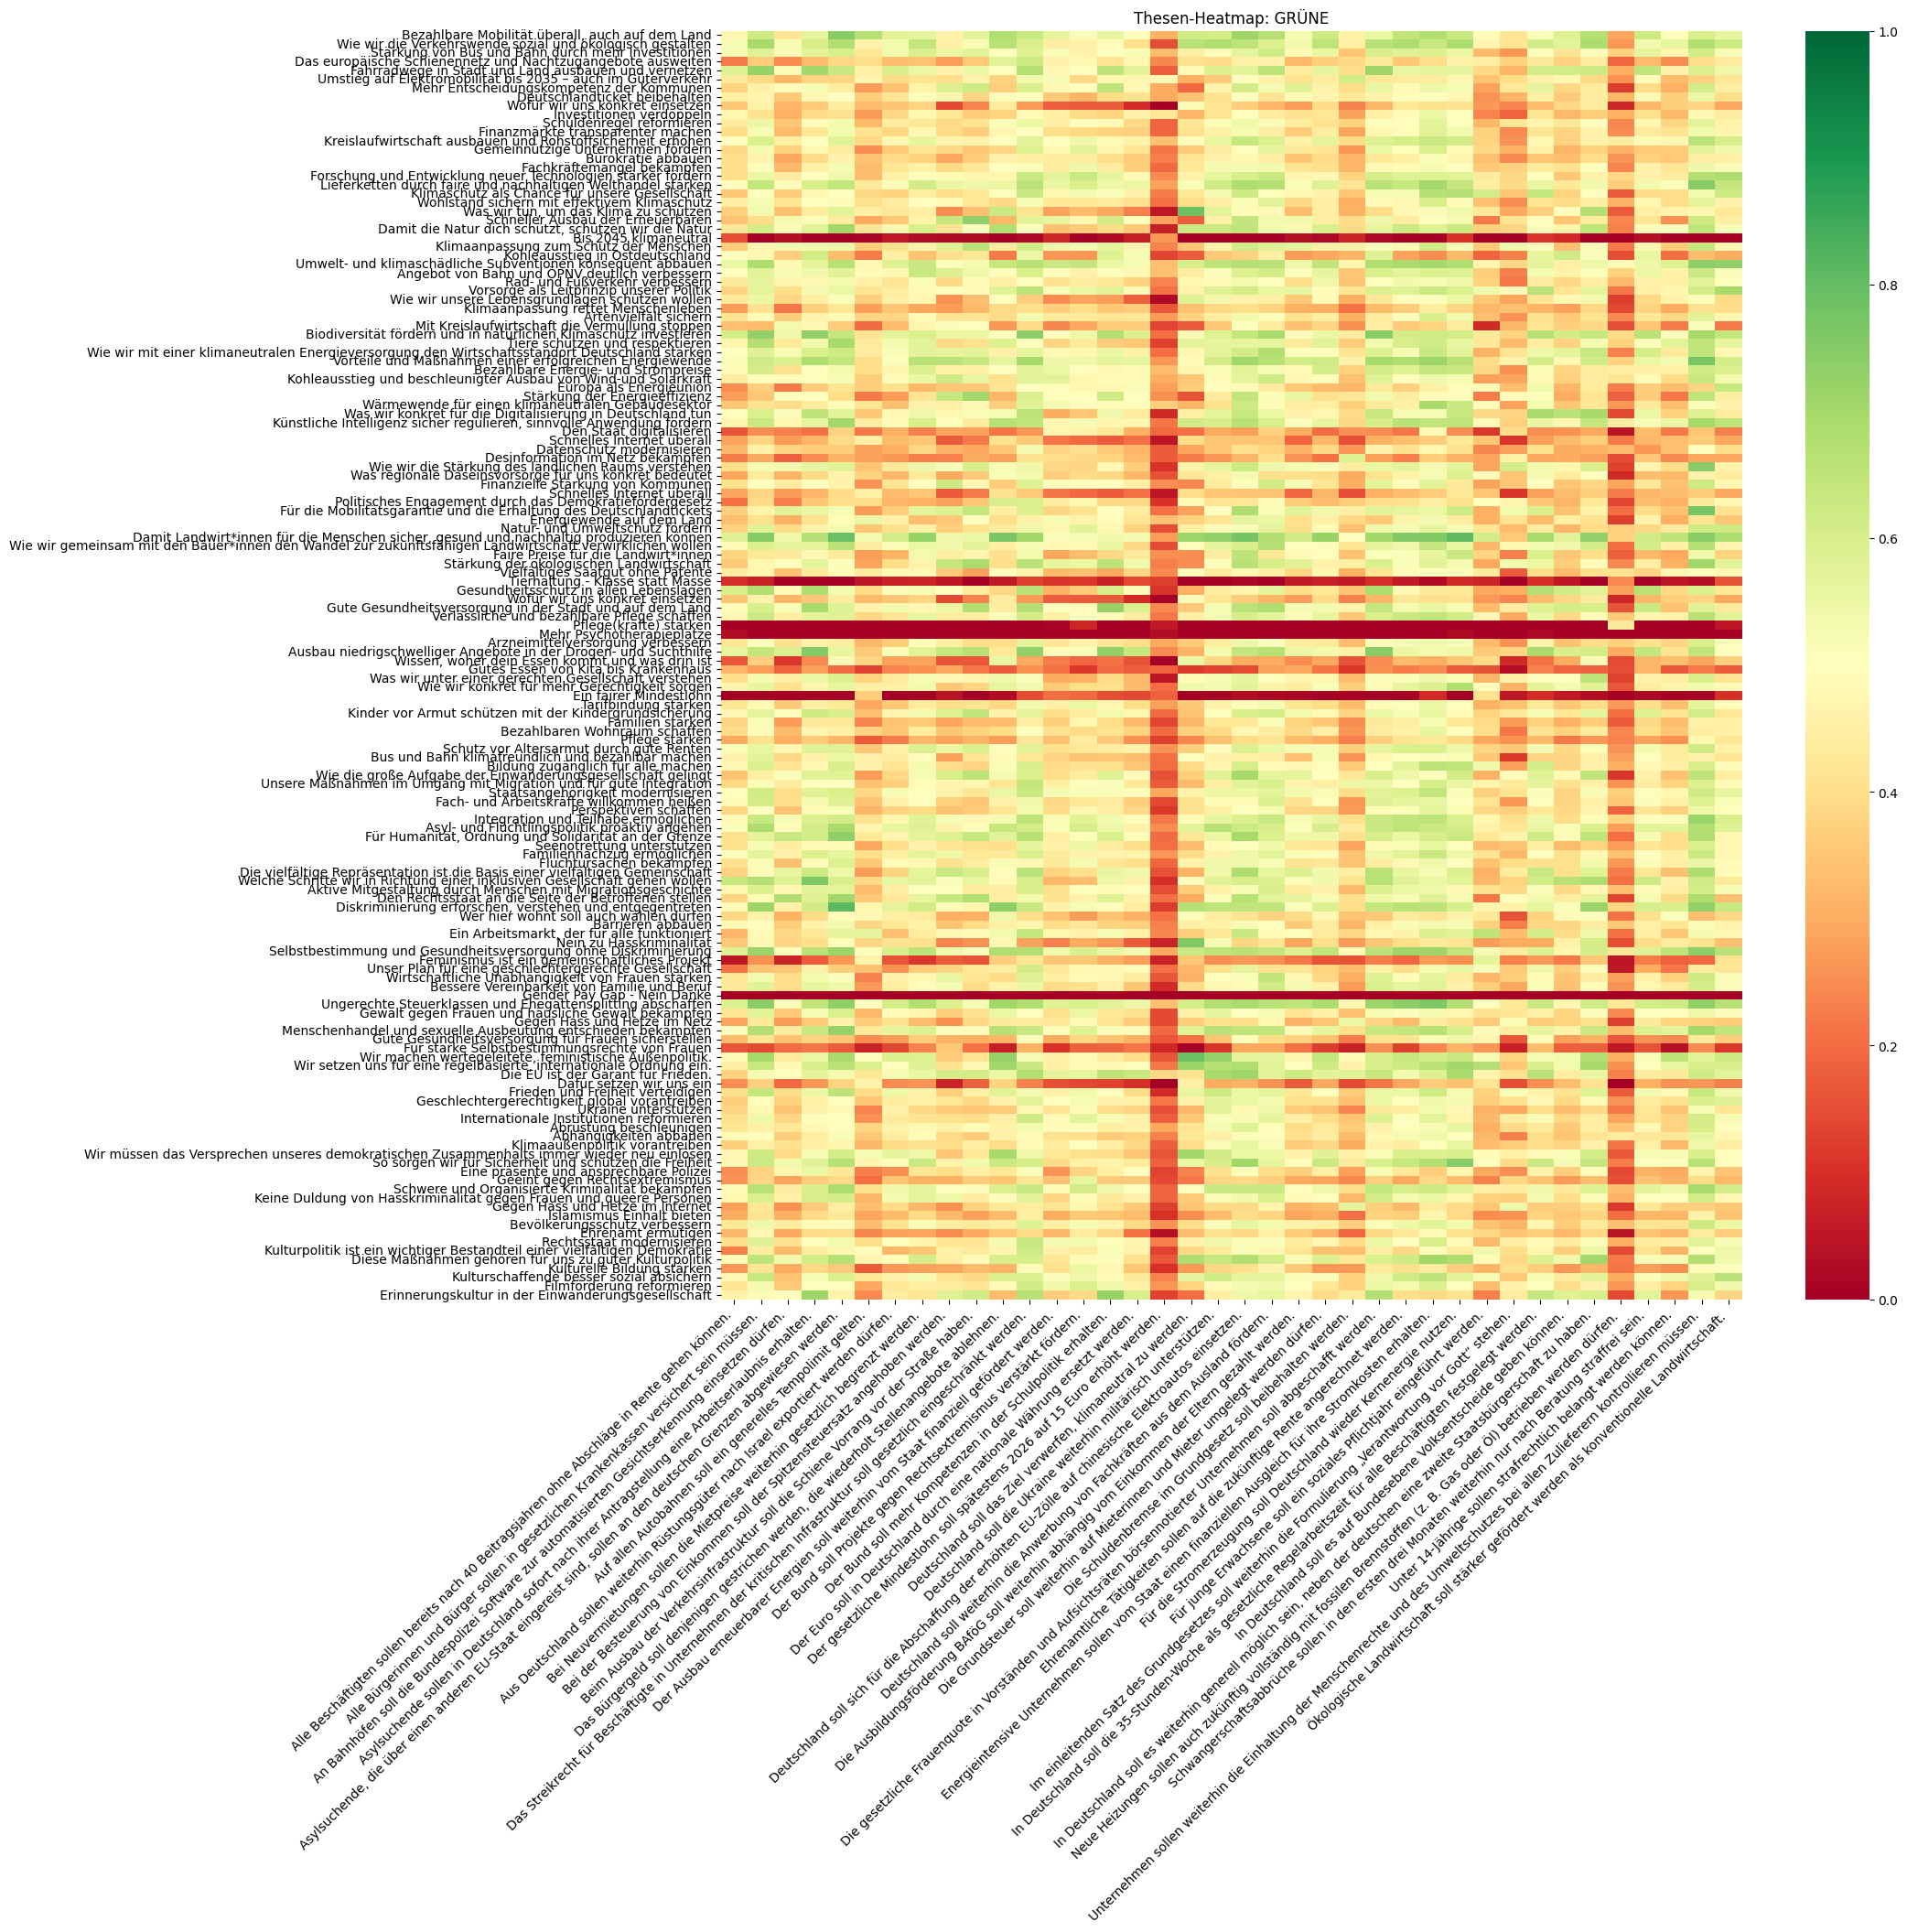

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2568\3420323385.py:21: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)


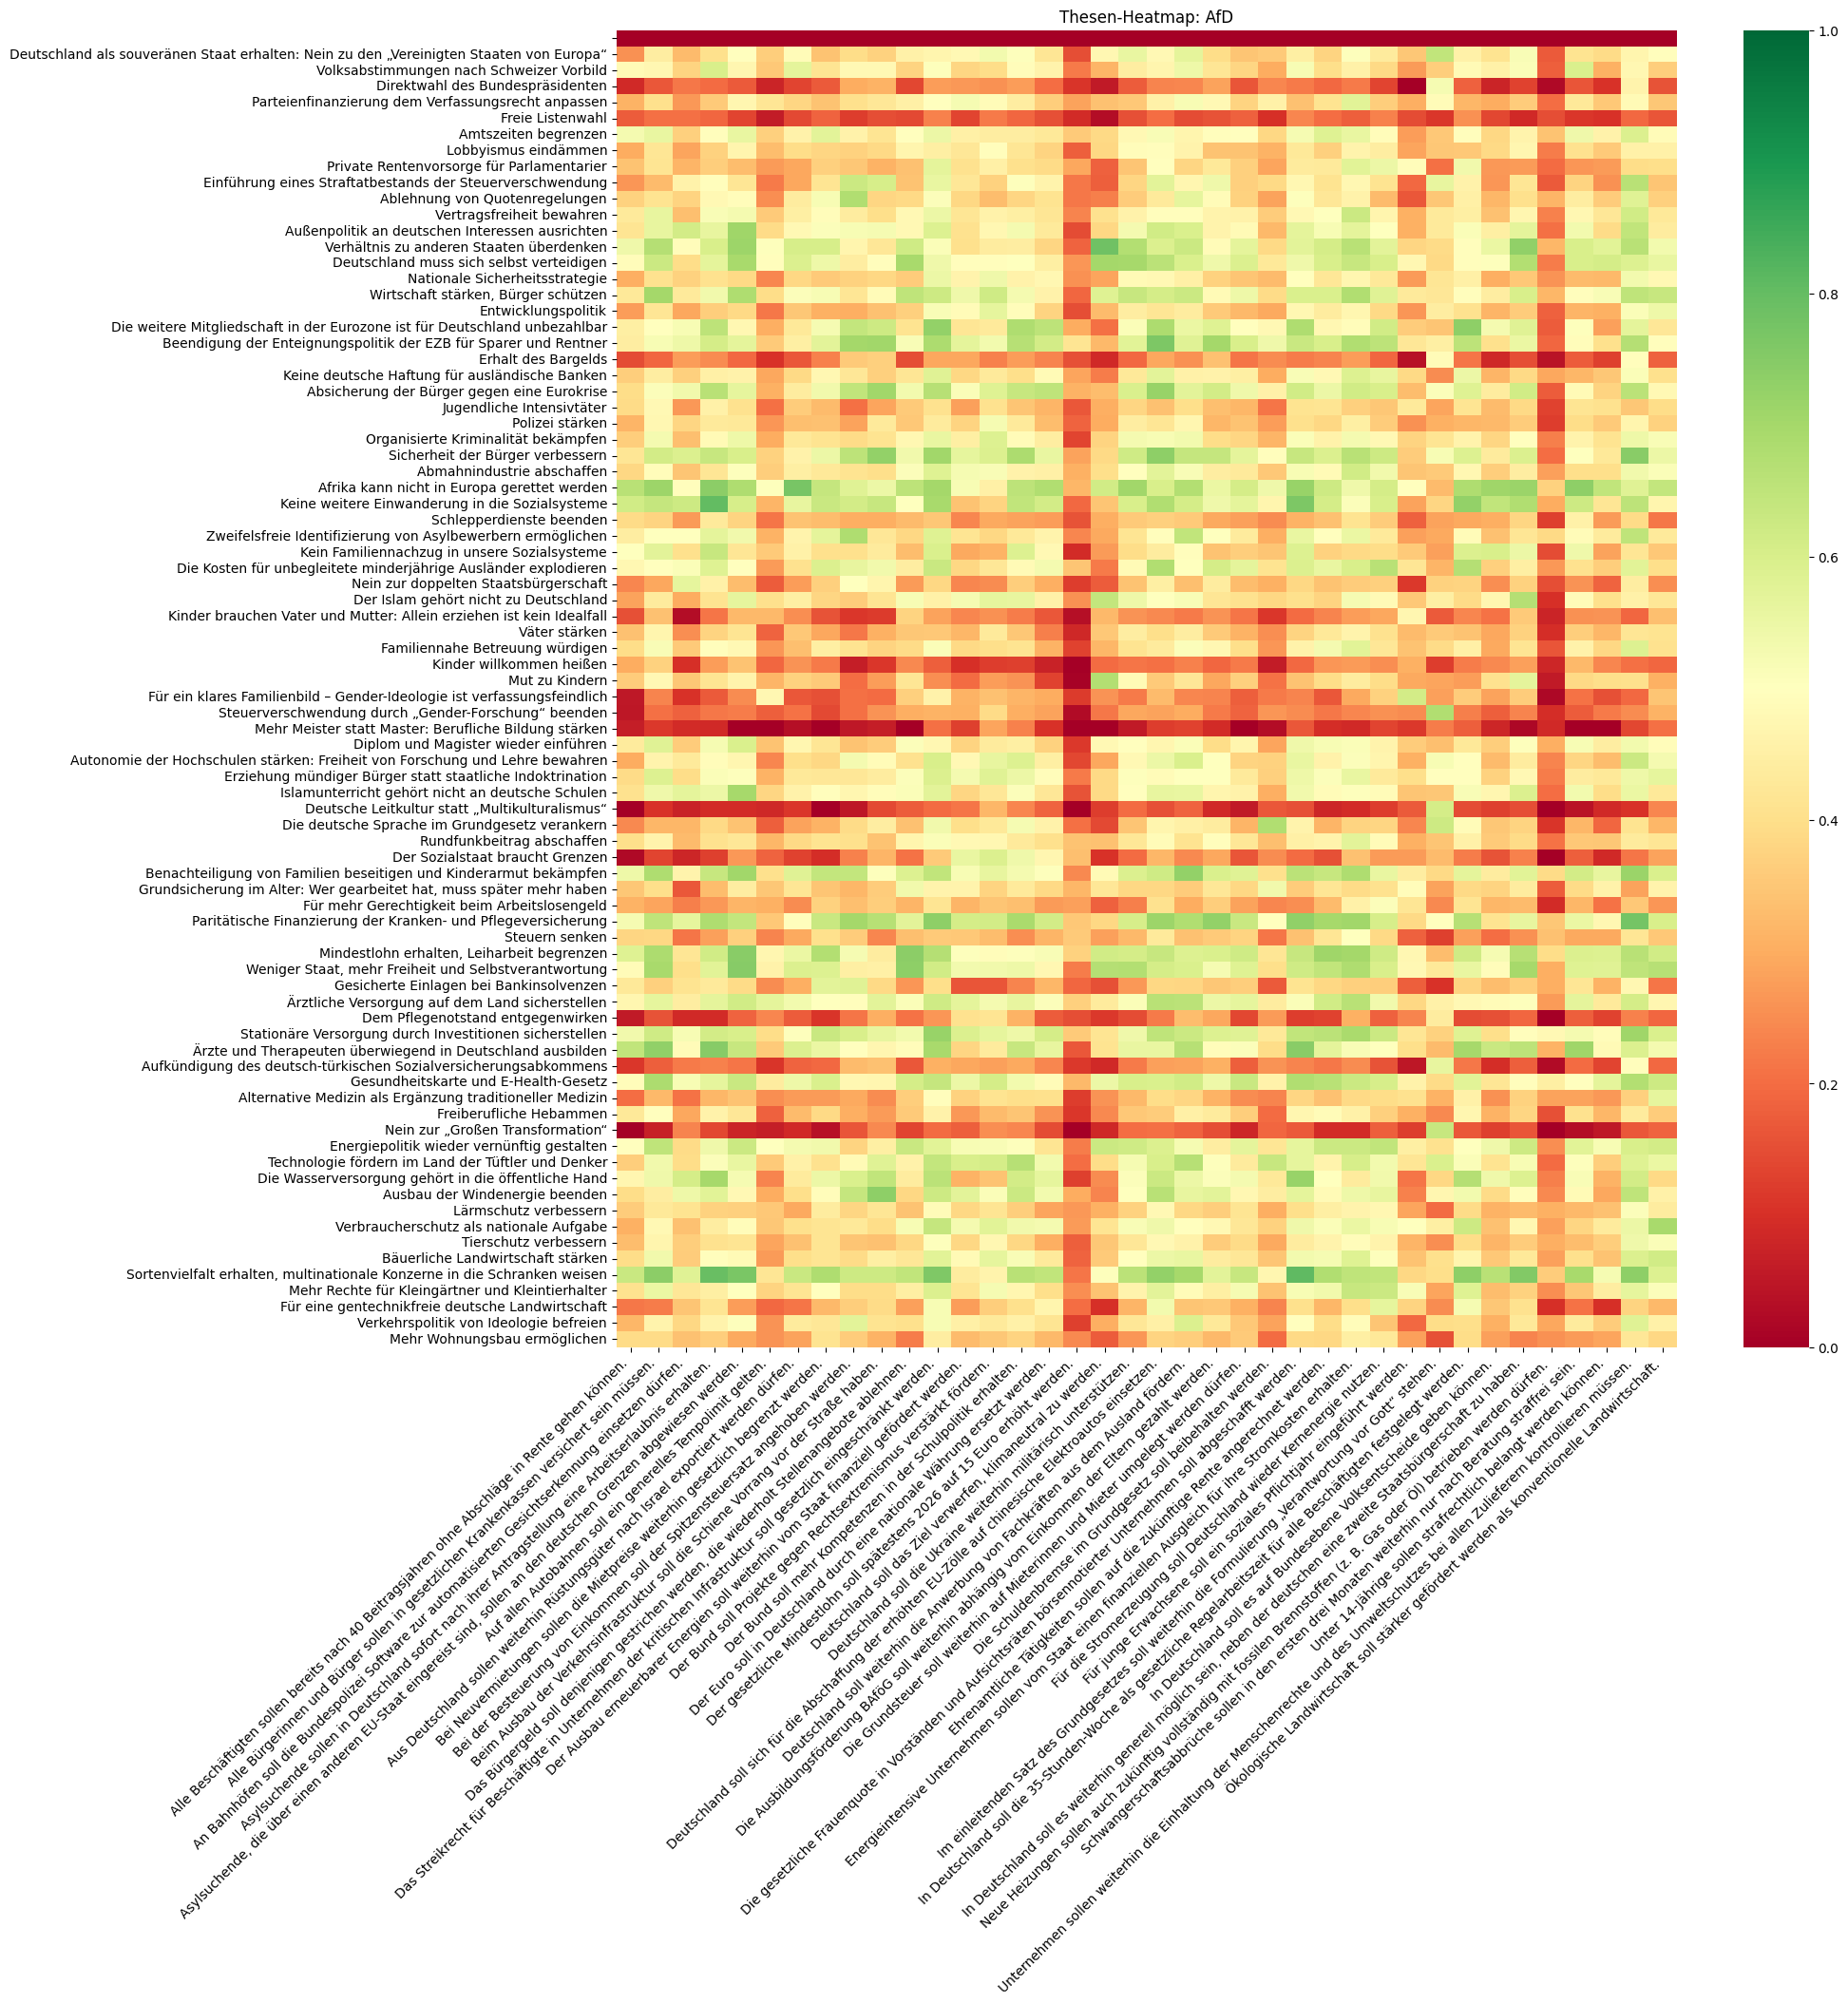

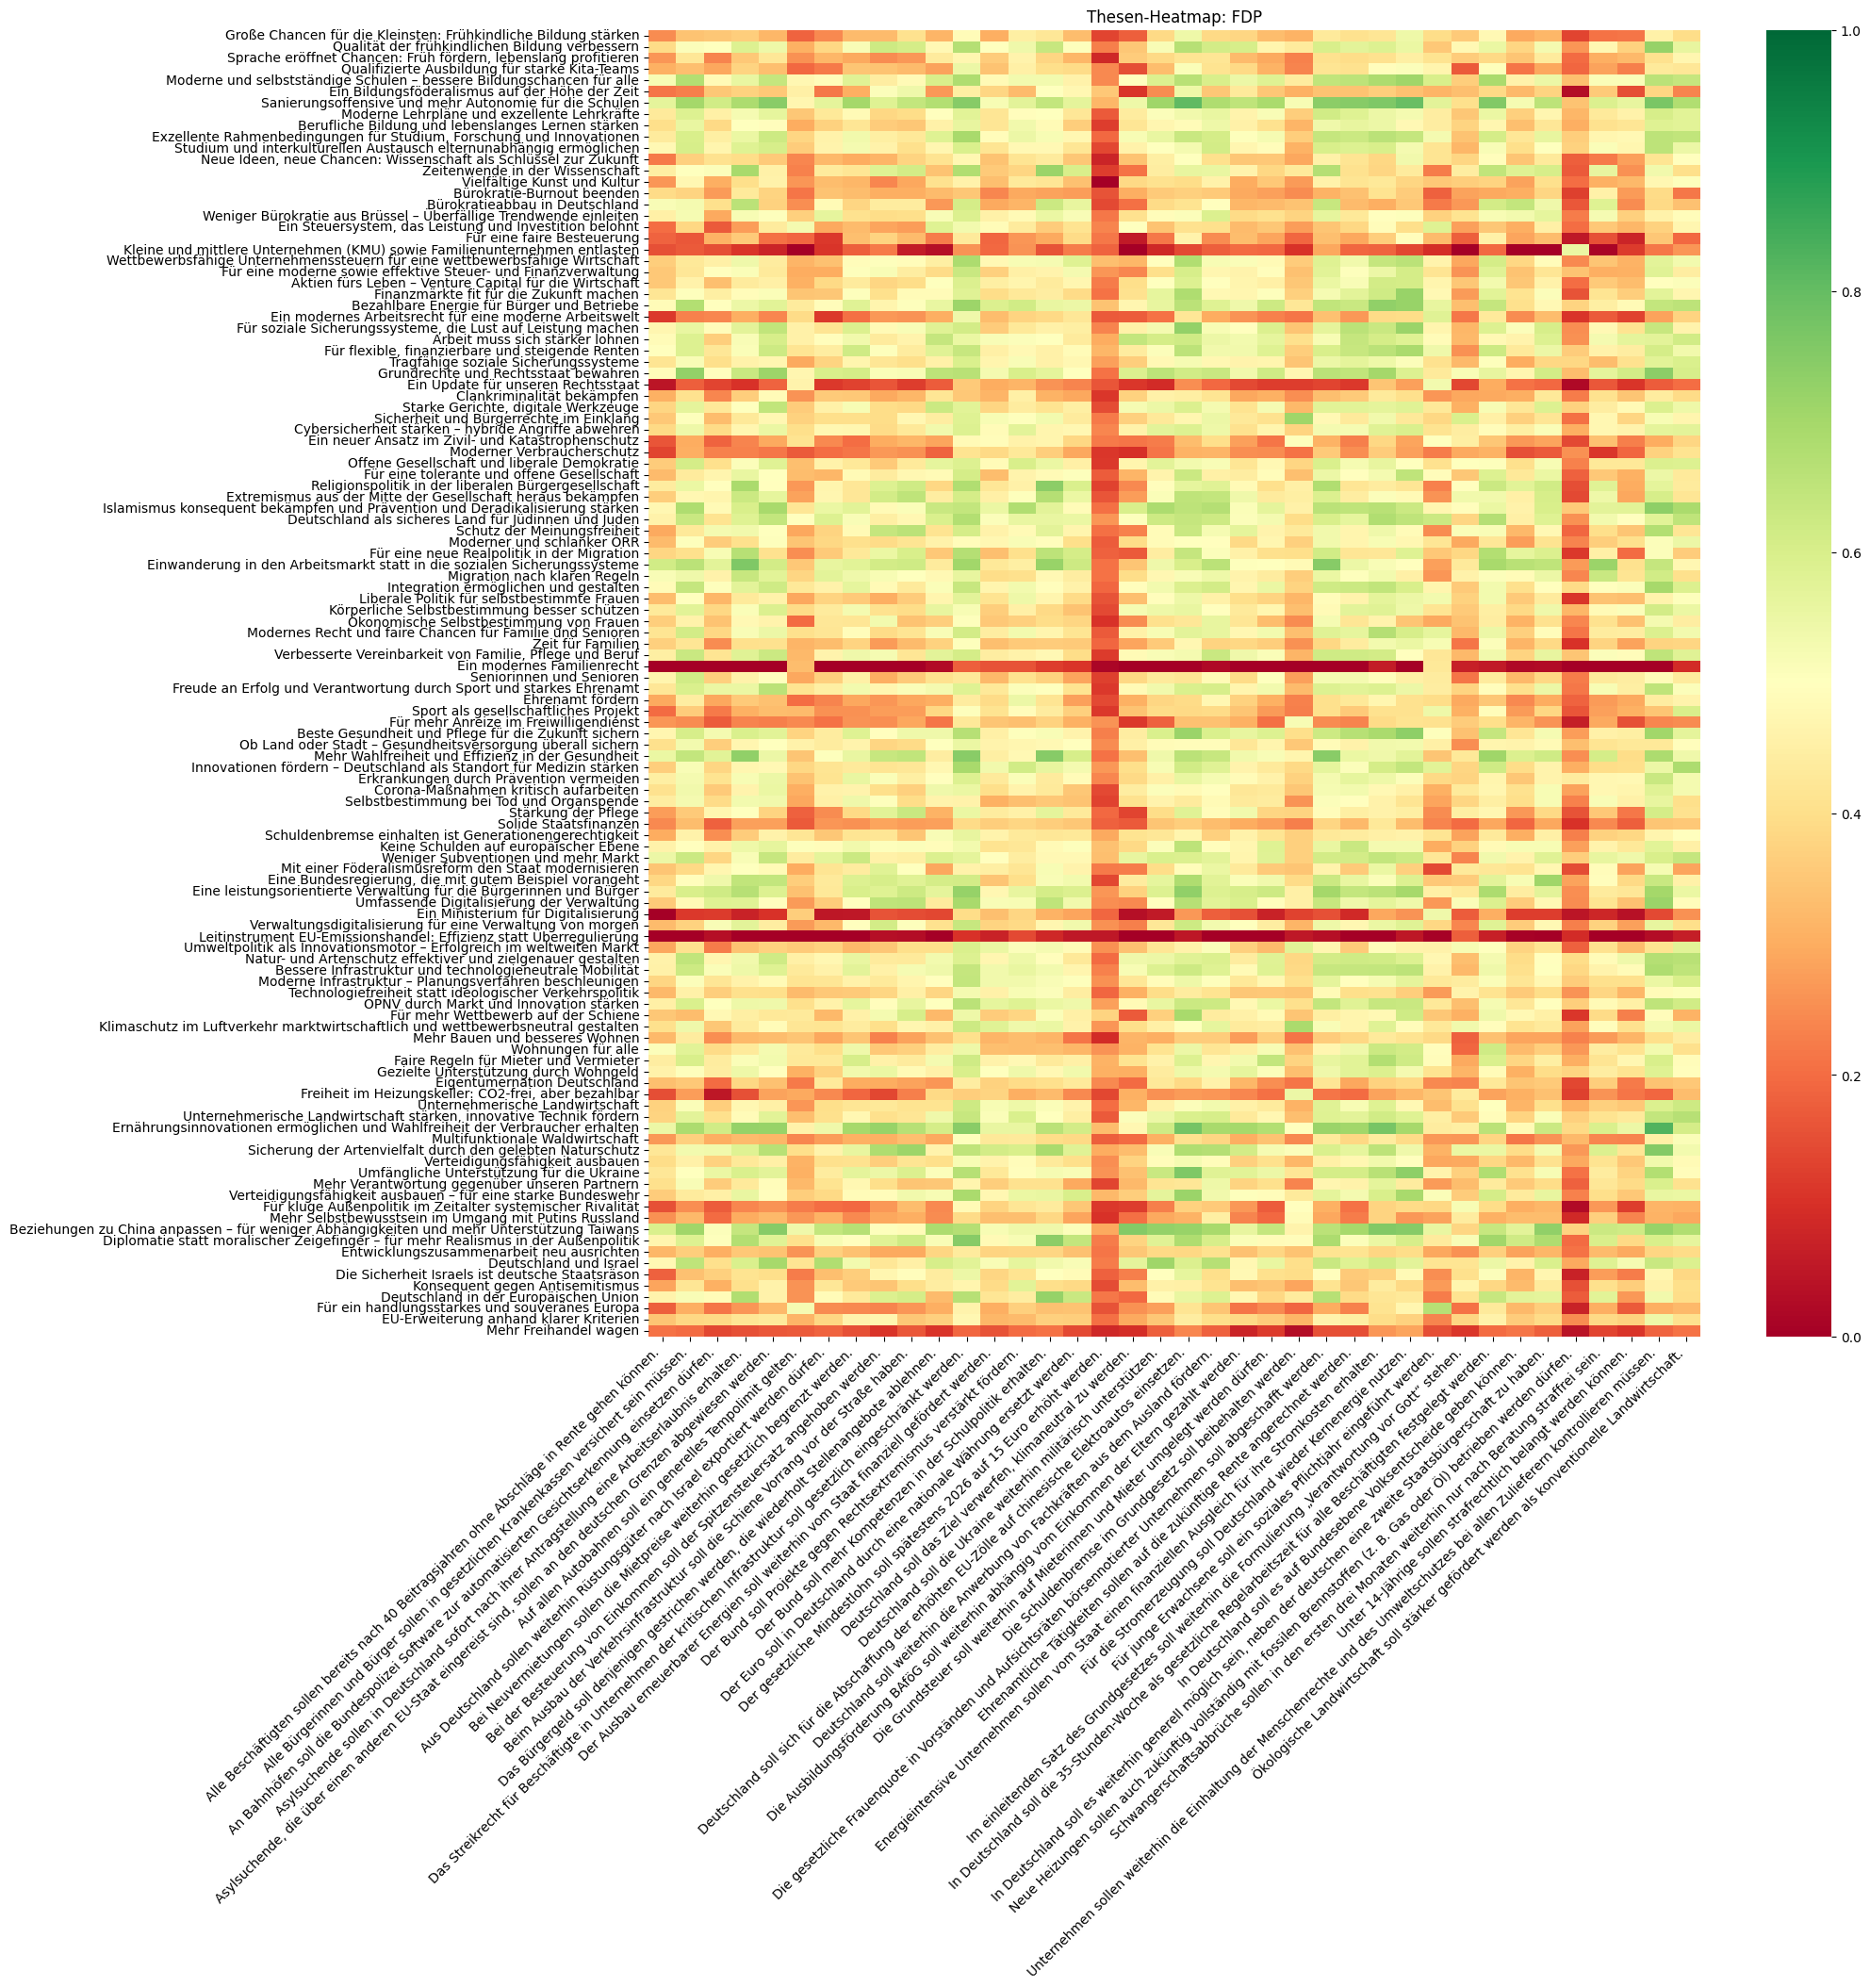

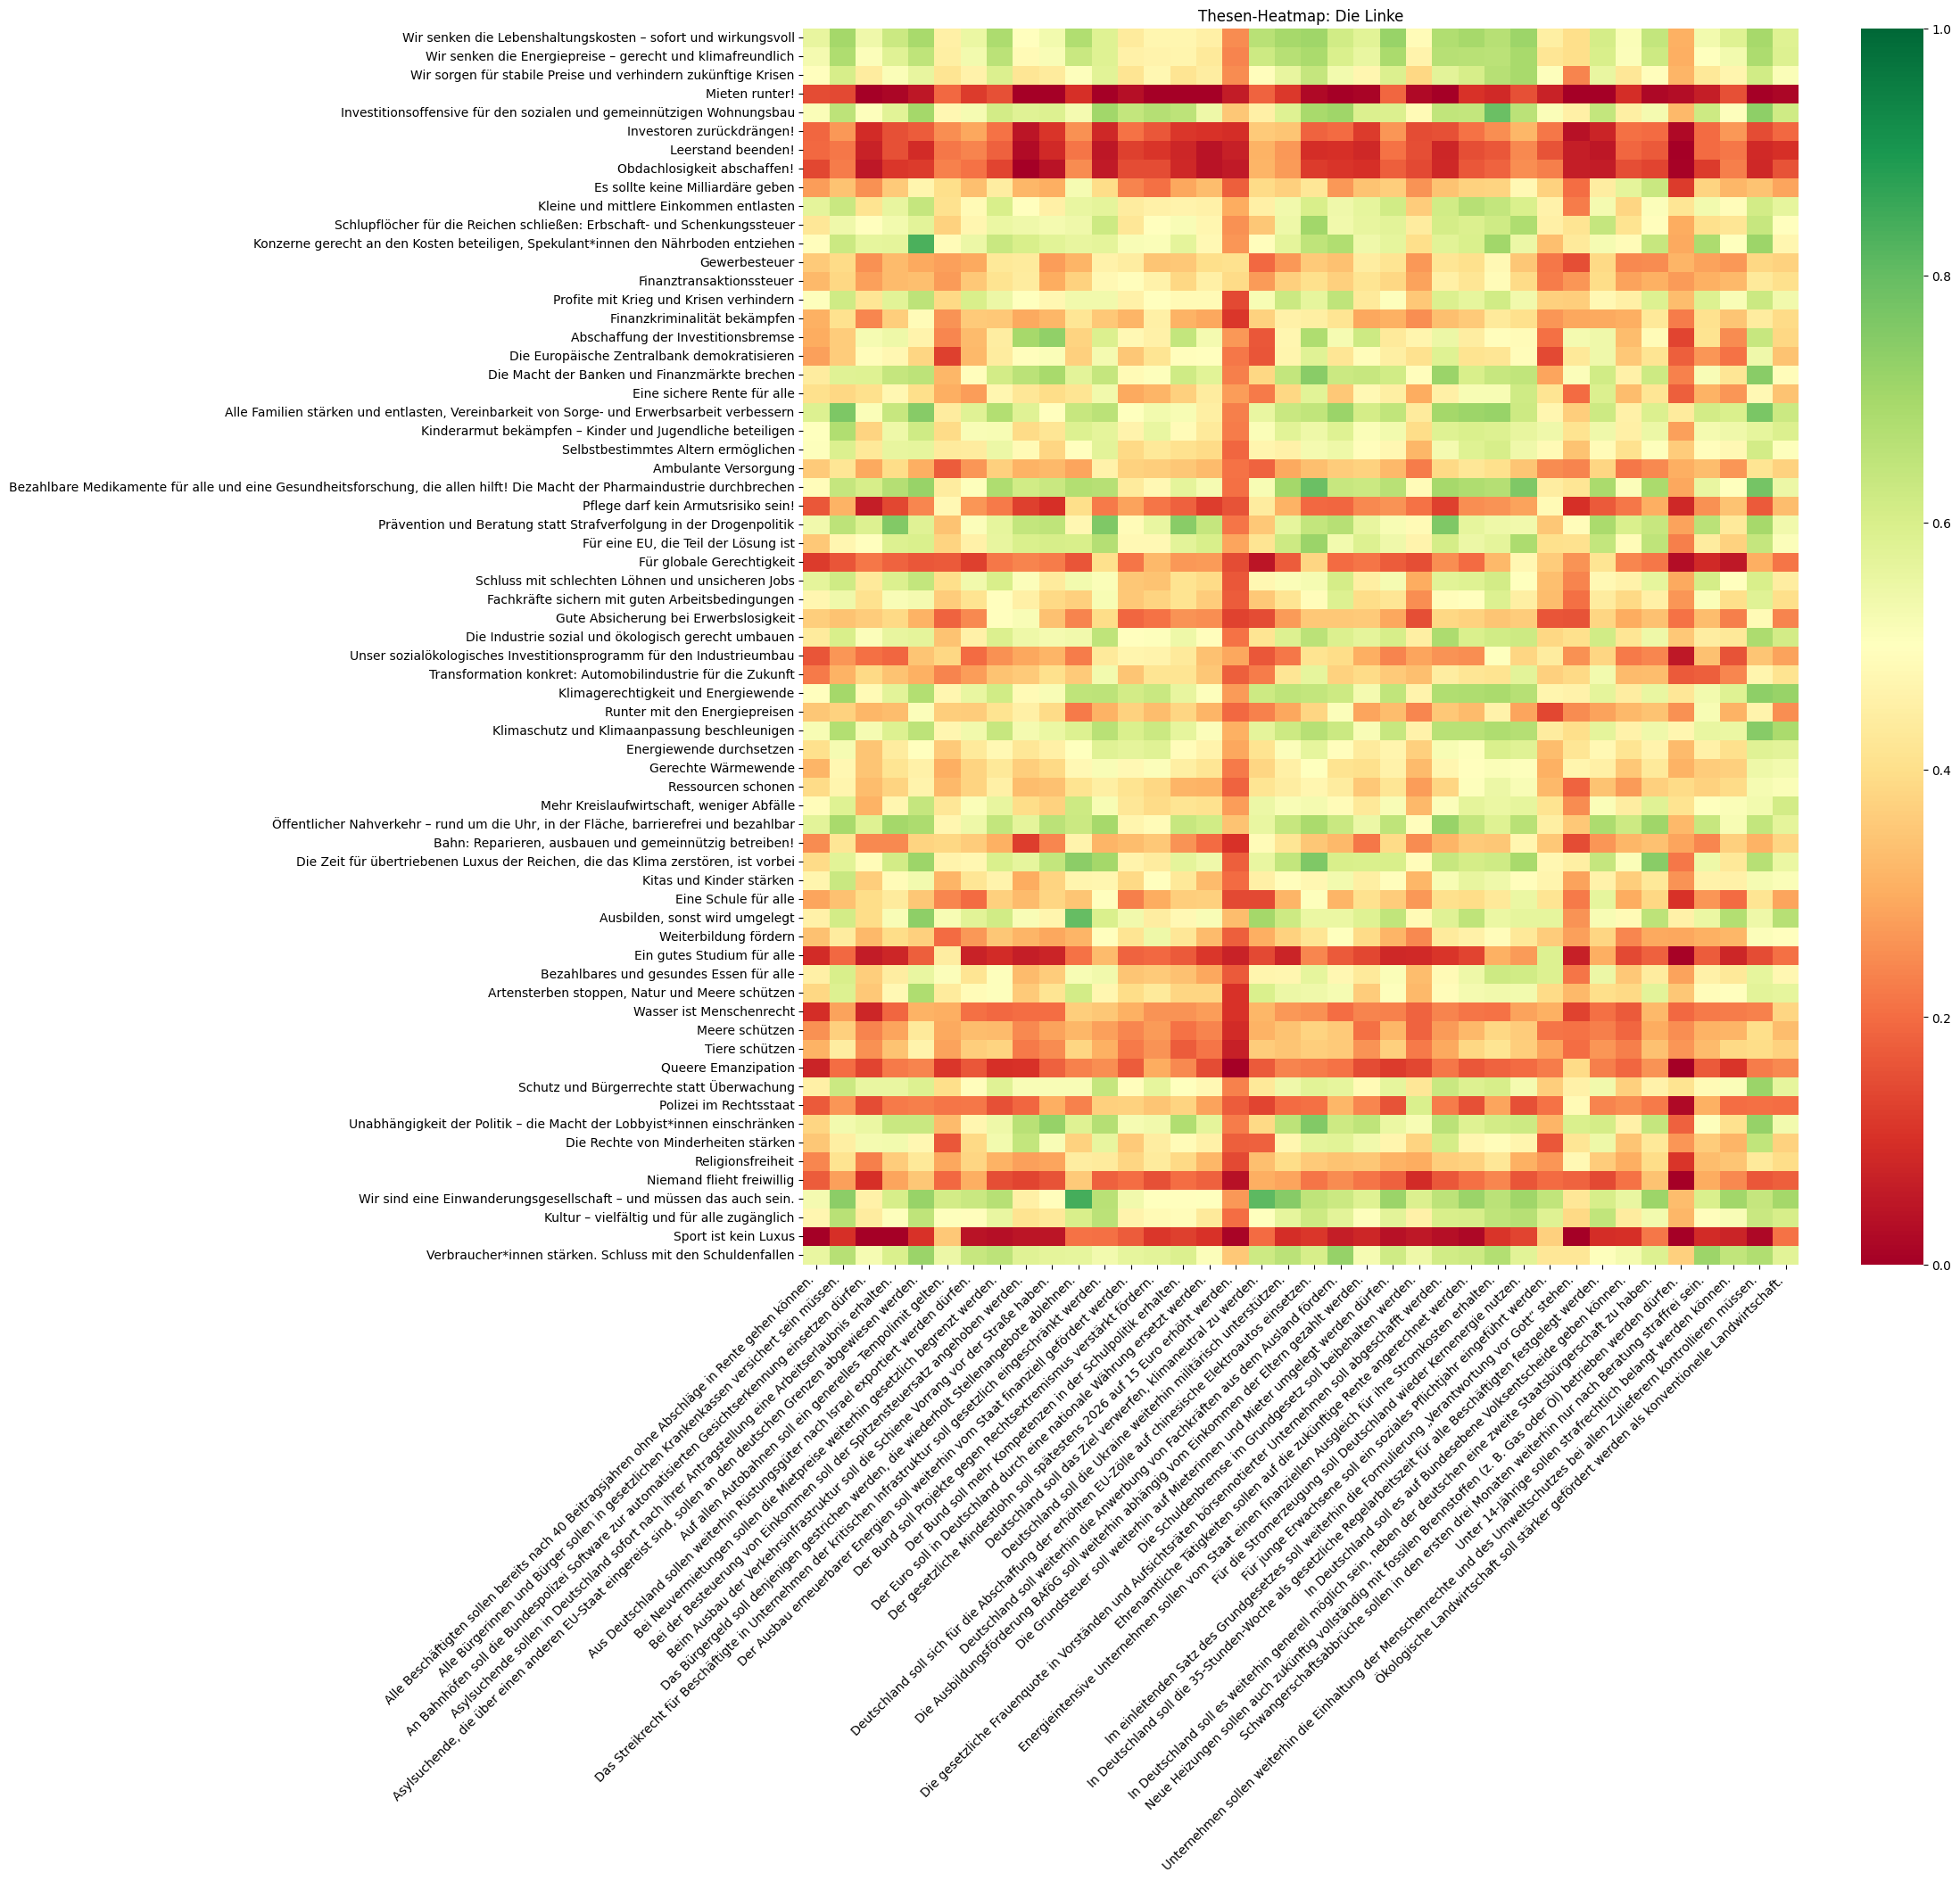

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.644178,0.633945,0.699656,0.661654,0.587612,0.613741
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.746884,0.746650,0.830769,0.739122,0.763966,0.728192
2,An Bahnhöfen soll die Bundespolizei Software z...,0.588551,0.680419,0.741290,0.622571,0.603022,0.618091
3,Asylsuchende sollen in Deutschland sofort nach...,0.791920,0.759645,0.805913,0.802573,0.756031,0.760241
4,"Asylsuchende, die über einen anderen EU-Staat ...",0.792500,0.811283,0.816068,0.766643,0.833762,0.746146
5,Auf allen Autobahnen soll ein generelles Tempo...,0.604513,0.666419,0.682060,0.568699,0.611718,0.539764
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,0.629517,0.609613,0.708937,0.770564,0.633566,0.677680
7,Bei Neuvermietungen sollen die Mietpreise weit...,0.705681,0.722071,0.765670,0.680176,0.685848,0.700238
8,Bei der Besteuerung von Einkommen soll der Spi...,0.687380,0.656673,0.710562,0.700111,0.695363,0.722473
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.719881,0.731846,0.749252,0.737025,0.731522,0.714005


In [6]:
predicted_theses_df = spacy_similarity_score_func(all_party_textes_df, labled_theses_df, plot=True)
predicted_theses_df

In [7]:
parties_list

['SPD', 'CDU / CSU', 'GRÜNE', 'AfD', 'FDP', 'Die Linke']

In [8]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def calc_prediction_scores_func(predicted_theses_df:pd.DataFrame, label_these_num_df:pd.DataFrame)->pd.DataFrame:
    scores_df = pd.DataFrame(columns= ['score'])
    scores_df['score'] = ['RMSE', 'MAE', 'R²']
    for col in predicted_theses_df.columns[1:]: 
        predicted_values = predicted_theses_df[col]
        true_values = label_these_num_df[col]

        rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
        r2 = r2_score(true_values, predicted_values)
        mae = mean_absolute_error(true_values, predicted_values)
        scores_df[col] = [rmse, mae, r2]


    return scores_df

calc_prediction_scores_func(predicted_theses_df, label_these_num_df)

,score,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,RMSE,0.395675,0.372998,0.387490,0.377564,0.389781,0.388338
1,MAE,0.341942,0.309225,0.302085,0.315319,0.328790,0.331742
2,R²,-0.540221,-0.294277,-0.495269,-0.478561,-0.443329,-0.560415


In [9]:
predicted_theses_df = spacy_similarity_score_func(all_party_textes_df, labled_theses_df, content= 'Text', plot=False)
calc_prediction_scores_func(predicted_theses_df, label_these_num_df)

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2568\3420323385.py:21: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_2568\3420323385.py:21: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_2568\3420323385.py:21: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_2568\3420323385.py:21: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_2568\3420323385.py:21: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_t

,score,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,RMSE,0.437237,0.434047,0.418570,0.459428,0.457720,0.469948
1,MAE,0.333548,0.320339,0.312215,0.358396,0.354839,0.384503
2,R²,-0.880795,-0.752612,-0.744759,-1.189245,-0.990319,-1.285173


In [10]:
for party_str in parties_list:
    party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]
    party_df.dropna(inplace=True)
    party_these_list = party_df['Text'].to_list()

    similarity_df = pd.DataFrame(columns=['party_these']+Labled_theses_list)

    for party_these in party_these_list:
        party_these_doc = nlp(party_these)
        row = [party_these]
        for label_these in Labled_theses_list:
            label_these_doc = nlp(label_these)
            similarity_score = party_these_doc.similarity(label_these_doc)
            row = row + [similarity_score]
        similarity_df.loc[len(similarity_df)] = row

    plt.figure(figsize=(18,18))
    sns.heatmap(similarity_df[Labled_theses_list], 
                cmap='RdYlGn', 
                annot= False,
                vmax= 1,
                vmin= 0,
                #yticklabels=similarity_df["party_these"]
                )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Thesen-Heatmap: {party_str}")
    plt.show()

    predicted_theses_df[party_str] = similarity_df[Labled_theses_list].mean().tolist()

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2568\865680615.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


NameError: name 'Labled_theses_list' is not defined

In [ ]:
predicted_theses_df

In [ ]:
labled_theses_df